In [9]:
## This is the assignment submission file.
import pandas as pd
from scipy import stats
import numpy as np
import os
dfg = pd.read_csv("data/chess_games.csv").copy()

In [10]:
def clean_function_games(dfg,local_path):
    dfg[['time_base', 'time_inc']] = dfg['time_increment'].str.split('+', expand=True).astype(int)
    dfg['rating_diff'] = dfg['white_rating'] - dfg['black_rating']
    dfg['opening_family'] = dfg['opening_fullname'].str.split(':').str[0].str.strip()
    dfg = dfg.drop(columns=['opening_response'])
    dfg['is_suspicios'] = dfg['turns'] < 5
    assert dfg['rating_diff'].notna().all()
    assert dfg.duplicated().sum() == 0
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    dfg.to_csv(local_path, index=False)
    print(f'Saved to {local_path}')
    return  dfg
clean_function_games(dfg,"data/processed/chess_games.csv")

Saved to data/processed/chess_games.csv


,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,...,opening_code,opening_moves,opening_fullname,opening_shortname,opening_variation,time_base,time_inc,rating_diff,opening_family,is_suspicios
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,...,D10,5,Slav Defense: Exchange Variation,Slav Defense,Exchange Variation,15,2,309,Slav Defense,False
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,Kennedy Variation,5,10,61,Nimzowitsch Defense,False
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,Leonardis Variation,5,10,-4,King's Pawn Game,False
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,Zukertort Variation,20,0,-15,Queen's Pawn Game,False
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,...,C41,5,Philidor Defense,Philidor Defense,NaN,30,3,54,Philidor Defense,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,20054,True,24,Resign,White,10+10,belcolt,1691,jamboger,1220,...,A80,2,Dutch Defense,Dutch Defense,NaN,10,10,471,Dutch Defense,False
20054,20055,True,82,Mate,Black,10+0,jamboger,1233,farrukhasomiddinov,1196,...,A41,2,Queen's Pawn,Queen's Pawn,NaN,10,0,37,Queen's Pawn,False
20055,20056,True,35,Mate,White,10+0,jamboger,1219,schaaksmurf3,1286,...,D00,3,Queen's Pawn Game: Mason Attack,Queen's Pawn Game,Mason Attack,10,0,-67,Queen's Pawn Game,False
20056,20057,True,109,Resign,White,10+0,marcodisogno,1360,jamboger,1227,...,B07,4,Pirc Defense,Pirc Defense,NaN,10,0,133,Pirc Defense,False


In [11]:
#AQ1 — Descriptive Statistics
dfg['rating_diff'] = (dfg['white_rating']- dfg['black_rating'])
dfg[['turns', 'rating_diff']].describe()

,turns,rating_diff
count,20058.000000,20058.000000
mean,60.465999,7.799880
std,33.570585,249.036667
min,1.000000,-1605.000000
25%,37.000000,-108.000000
50%,55.000000,3.000000
75%,79.000000,122.000000
max,349.000000,1499.000000


In [12]:
from scipy import stats

stats.shapiro(dfg['turns'].sample(5000))

ShapiroResult(statistic=np.float64(0.9553032911832878), pvalue=np.float64(1.263372153152749e-36))

In [8]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached fonttools-4.63.0-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


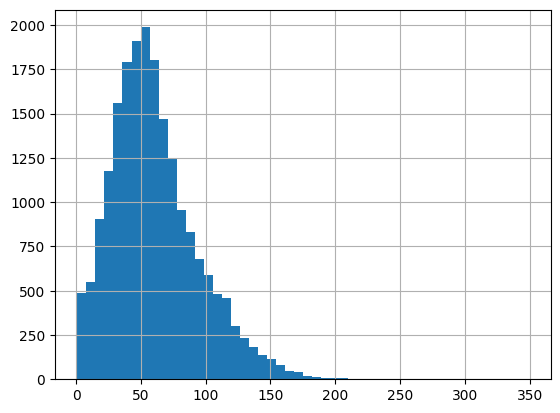

In [13]:
import matplotlib.pyplot as plt

dfg['turns'].hist(bins=50)
plt.show()

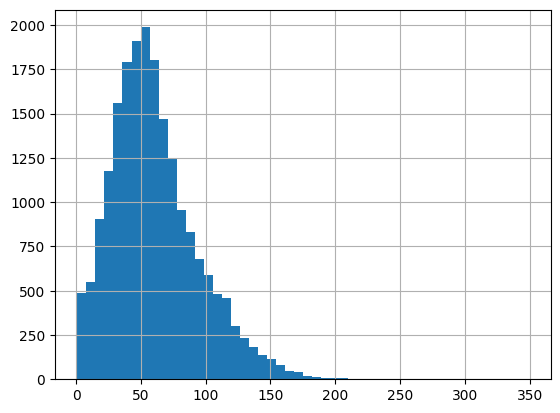

In [14]:
import matplotlib.pyplot as plt

dfg['turns'].hist(bins=50)
plt.show()

In [17]:
import numpy as np

dfg['log_turns'] = np.log1p(dfg['turns'])

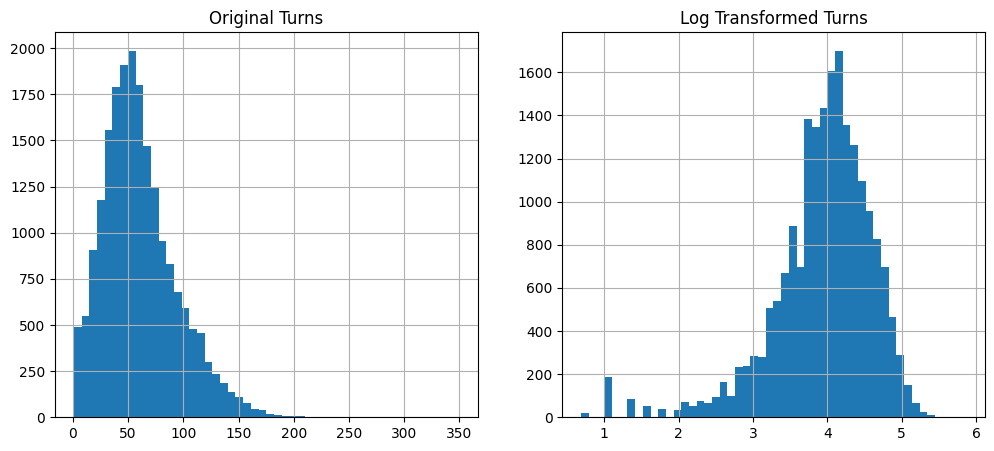

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
df['turns'].hist(bins=50)
plt.title("Original Turns")

plt.subplot(1,2,2)
dfg['log_turns'].hist(bins=50)
plt.title("Log Transformed Turns")

plt.show()

تفسير النتائج
1. Histogram

Original Turns يظهر انحرافًا موجبًا (Right Skewed)، مع ذيل طويل إلى اليمين بسبب بعض الألعاب الطويلة جدًا.
Log Transformed Turns أصبح أكثر تركّزًا وأقرب للشكل الجَرَسي، لكن ليس طبيعيًا تمامًا.

In [21]:
print("Original skewness:", dfg['turns'].skew())
print("Log skewness:", dfg['log_turns'].skew())

Original skewness: 0.8972837714383509
Log skewness: -1.370833885871163


التفسير:

قبل التحويل: انحراف موجب متوسط (0.897).
بعد التحويل: أصبح الانحراف سالبًا (-1.371).

هذا يعني أن التحويل اللوغاريتمي أزال الانحراف الموجب الزائد لكنه بالغ في التصحيح وجعل التوزيع منحرفًا لليسار.

In [22]:
from scipy import stats

orig_p = stats.shapiro(dfg['turns'].sample(5000, random_state=42))[1]
log_p = stats.shapiro(dfg['log_turns'].sample(5000, random_state=42))[1]

print("Original p-value:", orig_p)
print("Log p-value:", log_p)

Original p-value: 2.252502851023394e-34
Log p-value: 5.004107914228546e-47


بما انه p < 0.05
نرفض فرضية الطبيعة
Neither the original nor the log-transformed distribution follows a normal distribution.

In [17]:
#AQ3 — WHO Dataset
import pandas as pd

WHO_URL = "https://github.com/Priyankkoul/Life-Expectancy-WHO---Data-Analytics/blob/master/DATASET.csv?raw=true"

who = pd.read_csv(WHO_URL)

print("Shape:", who.shape)

# first_5_checks(who, "WHO")

Shape: (2938, 22)


In [18]:
who.columns = who.columns.str.strip()

In [19]:
numeric_df = who.select_dtypes(include='number')

In [20]:
corr_matrix = numeric_df.corr()

life_corr = corr_matrix['Life expectancy'].sort_values(ascending=False)

print(life_corr.head(10))

Life expectancy                    1.000000
Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Diphtheria                         0.479495
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
Name: Life expectancy, dtype: float64


In [21]:
top3 = life_corr.drop('Life expectancy').head(3)

print(top3)

Schooling                          0.751975
Income composition of resources    0.724776
BMI                                0.567694
Name: Life expectancy, dtype: float64


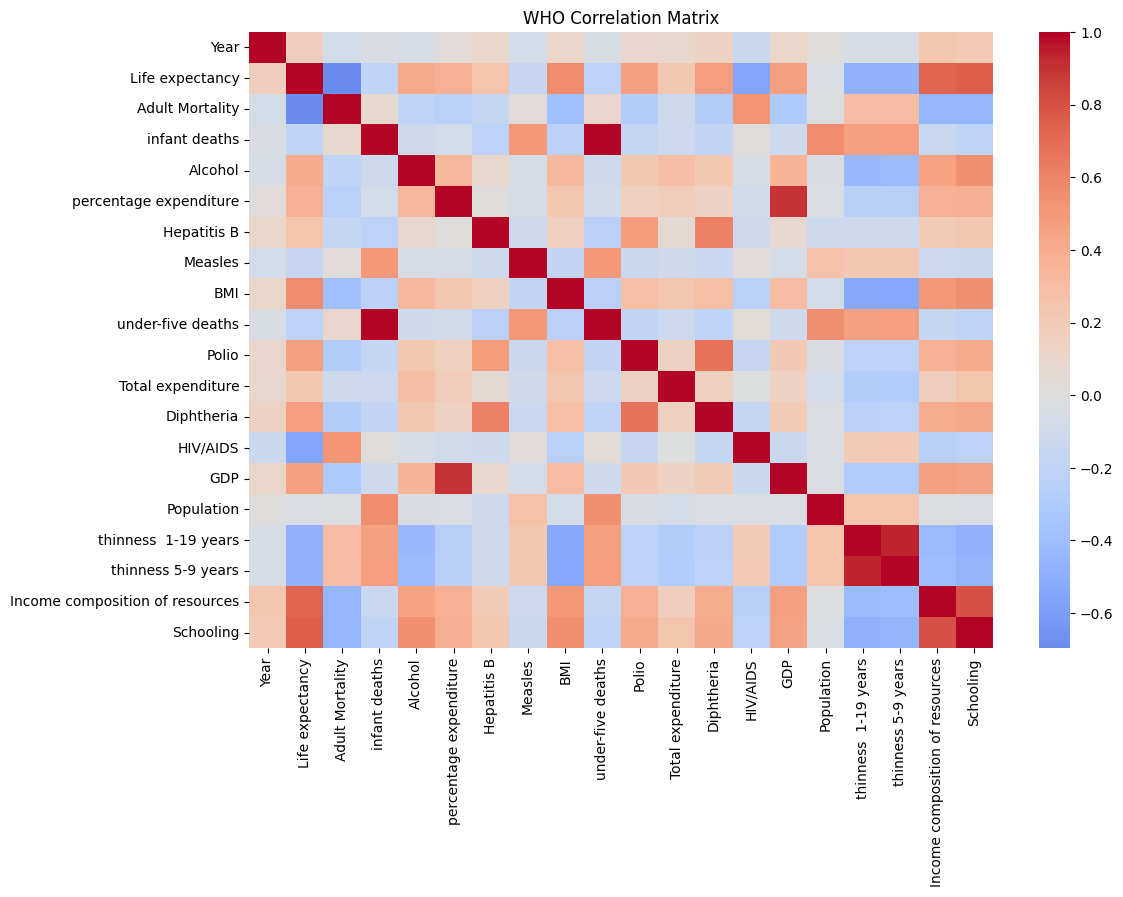

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("WHO Correlation Matrix")
plt.show()

In [23]:
pip install seaborn

     ------------------------------------ 294.9/294.9 kB 364.0 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
#AQ4 — Chi-Square Test
dfg['rating_group'] = pd.cut(
    dfg['white_rating'],
    bins=[0,1200,1600,2000,3000],
    labels=['Beginner','Intermediate','Advanced','Expert']
)

In [24]:
pd.crosstab(dfg['rating_group'], dfg['winner'])

winner,Black,Draw,White
rating_group,,,
Beginner,990,65,550
Intermediate,4457,382,4426
Advanced,3094,384,3916
Expert,566,119,1109


In [25]:
from scipy.stats import chi2_contingency

table = pd.crosstab(dfg['rating_group'], dfg['winner'])

chi2, p, dof, expected = chi2_contingency(table)

In [26]:
print("Contingency Table:")
print(table)

print("\nChi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Contingency Table:
winner        Black  Draw  White
rating_group                    
Beginner        990    65    550
Intermediate   4457   382   4426
Advanced       3094   384   3916
Expert          566   119   1109

Chi-square statistic: 382.9599422939785
p-value: 1.2854581797142245e-79
Degrees of freedom: 6


In [27]:
alpha = 0.05

if p < alpha:
    print("Reject H0: There is a significant association between rating group and winner.")
else:
    print("Fail to reject H0: No significant association found.")

Reject H0: There is a significant association between rating group and winner.


In [28]:
import numpy as np

n = table.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print("Cramer's V:", round(cramers_v, 3))

Cramer's V: 0.098


In [31]:
#AQ5 — Confidence Intervals
rated = dfg[df['rated']==True]['turns']
unrated = df[df['rated']==False]['turns']

In [32]:
#1. Parametric Confidence Interval
from scipy import stats
from scipy.stats import t as t_dist

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)
    h = se * t_dist.ppf((1 + confidence) / 2., n - 1)
    return mean - h, mean + h

rated_ci = confidence_interval(rated)
unrated_ci = confidence_interval(unrated)

print("Rated 95% CI:", rated_ci)
print("Unrated 95% CI:", unrated_ci)

Rated 95% CI: (np.float64(61.44233966617739), np.float64(62.48276092187585))
Unrated 95% CI: (np.float64(53.26225453567002), np.float64(55.28091738336662))


In [33]:
#2. Bootstrap Confidence Interval
import numpy as np

def bootstrap_ci(data, n_boot=1000, confidence=0.95):
    rng = np.random.default_rng(42)

    means = [
        rng.choice(data, len(data), replace=True).mean()
        for _ in range(n_boot)
    ]

    alpha = (1 - confidence) / 2

    return np.percentile(
        means,
        [100 * alpha, 100 * (1 - alpha)]
    )

rated_boot = bootstrap_ci(rated.values)
unrated_boot = bootstrap_ci(unrated.values)

print("Rated Bootstrap CI:", rated_boot)
print("Unrated Bootstrap CI:", unrated_boot)

Rated Bootstrap CI: [61.43237388 62.49975549]
Unrated Bootstrap CI: [53.20470151 55.29671407]
